# Midterm Project - Pet Preference Prediction Using Machine Learning.

<p align="center"><img src="header.png" alt="Pet Preference" width="600"/></p>


1. What is the problem?
The problem is to build a machine learning model that predicts whether a person is more likely to be a cat person, dog person, both, or neither based on demographic, social, and behavioral features such as age, gender, type of settlement, education level, income, and media habits. The model aims to identify how lifestyle and background factors correlate with personal preferences toward pets.

2. Why is it important?
Understanding personality and lifestyle correlations with pet preferences can be valuable for marketing, social research, and behavioral psychology. Pet-related companies and advertisers can use such insights to better target products and services, while sociologists and psychologists may use the findings to explore cultural and demographic influences on human–animal relationships. It also demonstrates how social survey data can be turned into behavioral prediction through ML.

3. How will the solution be used?
The trained model can be integrated into survey analytics tools or marketing platforms to automatically classify respondents or customers into preference categories. It could also be used for visualization and demographic analysis—showing patterns like “younger urban males prefer dogs” or “rural, older respondents tend to like both.” Researchers can apply it to new datasets to explore trends across regions or time.

4. Who will benefit from this solution?
	•	Marketing and advertising teams: to personalize campaigns for pet-related products.
	•	Sociologists and behavioral scientists: to study human-animal affinity as a social pattern.
	•	Survey organizations: to enrich responses with automated behavioral tagging.
	•	Pet industry businesses: to understand their customer base more precisely.
	•	General public: through more relevant pet content and product recommendations.

**Dataset**: 
Unfortunately there are not many publicly available datasets specifically about pet preferences. The only one I was able to find is a survey from a Russian social research organization VCIOM, which includes questions about pet ownership and preferences along with demographic and lifestyle information. The dataset can be accessed [here](https://wciom.ru/analytical-reviews/analiticheskii-obzor/publichnaja-zhizn-domashnikh-zhivotnykh).

This dataset contains a variety of features including what type of pets people own, their preferences for cats or dogs, age. Also the dataset has some infrastructure questions like whether there is a pet store nearby, and what other people are saying about pets in their social circles which we will ignore because we are interested in predicting pet preference based on demographic and lifestyle features only.

**Author**: Yuri Golub

**Date**: November 2025

## 1. Import Libraries

<!-- TODO: Import all necessary libraries for data analysis, visualization, and modeling -->

In [37]:
import csv
from collections import defaultdict

import pandas as pd
import numpy as np
import pyreadstat

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, mutual_info_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer


import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

SEED = 42

## 2. Load and Prepare Data

<!--
Evaluation Criteria - Reproducibility (1 point max):
- 0 points: Not possible to execute the notebook and the training script. Data is missing or not easily accessible
- 1 point: It's possible to re-execute the notebook and the training script without errors. 
  The dataset is committed in the project repository or there are clear instructions on how to download the data

TODO: 
- Load your dataset
- Either commit the dataset to the repository OR provide clear download instructions
- Ensure the data loading process is reproducible
-->

The first challange that I faced was that the dataset is in SPSS file format (.sav) which is not natively supported by pandas. To load the data, I used the `pyreadstat` library which can read SPSS files and convert them into pandas DataFrames.

Also I had to deal with the fact that the dataset is in Russian language, so I used ChatGPT to translate the questions and answers which were the not that big in number.


Let'd see how to load the data:

```python

In [3]:
df_src, meta = pyreadstat.read_sav("animals.sav", apply_value_formats=True) # SPSS file format 
df_src.head(2)

,ID,SEX,AGE,FO,TIP,dzh1_1,dzh1_2,dzh1_3,dzh1_4,dzh1_5,dzh1_6,dzh1_7,dzh1_8,dzh1_9,dzh1_10,dzh1_11,dzh1_12,dzh2_1,dzh2_2,dzh2_3,dzh2_4,dzh2_5,dzh2_6,dzh2_7,dzh2_8,dzh2_9,dzh2_10,dzh2_11,dzh2_12,dzh3,dzh4,dzh5_1,dzh5_2,dzh5_3,dzh5_4,dzh5_5,dzh5_6,dzh5_7,dzh5_8,dzh5_9,dzh5_10,dzh5_11,dzh5_12,dzh5_13,TV,d1,EDU,DOHOD_0,PROF1,PROF2,PROF3,weight1
0,07cff176410cef03,Мужской,23.0,Центральный федеральный округ,Село,Беспородная собака,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ничего,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Нет,5- полностью удовлетворен,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Редко, но не менее одного раза в полгода",Провожу в интернете более четырех часов ежедневно,"Среднее профессиональное (техникум, колледж, ПТУ)",Среднее,"Работаю по договору, контракту в найме (за иск...","Я работаю в КОММЕРЧЕСКОЙ организации, ее цель ...",Транспортировка и хранение (складское хозяйств...,1.812298
1,07cfd2f75c4ce44a,Мужской,19.0,Южный федеральный округ,Село,"Нет, домашних животных нет",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Выгул агрессивных собак без намордника,"Отсутствие уборки за собаками в доме (в лифте,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Не смотрю,Провожу в интернете более четырех часов ежедневно,Основное общее образование: окончил 9 (раньше ...,Плохое,"Работающий учащийся, студент","Я работаю в КОММЕРЧЕСКОЙ организации, ее цель ...","Информационные технологии, связь, интернет Вкл...",1.784097


In [4]:
df_src.shape

(1604, 52)

In [5]:
df_src.dtypes

ID           object
SEX        category
AGE         float64
FO         category
TIP        category
dzh1_1     category
dzh1_2     category
dzh1_3     category
dzh1_4     category
dzh1_5     category
dzh1_6     category
dzh1_7     category
dzh1_8     category
dzh1_9     category
dzh1_10    category
dzh1_11    category
dzh1_12    category
dzh2_1     category
dzh2_2     category
dzh2_3     category
dzh2_4     category
dzh2_5     category
dzh2_6     category
dzh2_7     category
dzh2_8     category
dzh2_9     category
dzh2_10    category
dzh2_11    category
dzh2_12    category
dzh3       category
dzh4       category
dzh5_1     category
dzh5_2     category
dzh5_3     category
dzh5_4     category
dzh5_5     category
dzh5_6     category
dzh5_7     category
dzh5_8     category
dzh5_9     category
dzh5_10    category
dzh5_11    category
dzh5_12    category
dzh5_13    category
TV         category
d1         category
EDU        category
DOHOD_0    category
PROF1      category
PROF2      category


### Let's extract questions.

In [6]:
with open("questions.txt",'w+',encoding='utf-8') as f:
    for _, label in zip(meta.column_names, meta.column_labels):
        if label is not None:
            f.write(label + "\n")

print("Questions extracted to questions.txt")

Questions extracted to questions.txt


We have the questions. So now let's extract all the answers per question in a csv file for easier translation.

In [7]:
# Generating dataset using below
to_translate = [[col, v] for col, dtype in df_src.dtypes.items() if dtype == 'category' for v in df_src[col].unique().tolist() ]
pd.DataFrame(to_translate, columns=["column", "value"]).drop_duplicates().to_csv("to_translate.csv", index=False)

Now using the ChatGPT let's translate both questions.txt and to_translate.csv files. With the csv file we also ask to generate a single word label for every translated answer, e.g. TIP(column)->City with population from 50 thousand to 100 thousand(translated answer) -> city_medium (label).

After translation we put the translated answers into files questions_translated.txt and to_translate_with_labels.csv.

Now lets create a lookup dictionary for our dataset and create a new dataframe with translated labels instead of russian text.

In [8]:

with open("to_translate.csv", newline='', encoding='utf-8') as fo: # original
    with open("to_translate_with_labels.csv", newline='', encoding='utf-8') as ft: # translation
        orig_reader = csv.DictReader(fo)
        translation_reader = csv.DictReader(ft)
        labels = list(zip(orig_reader, translation_reader))

lbl_lookup = defaultdict(dict)
for ru,en in labels:
    lbl_lookup[ru['column']][ru['value']]=en['label']
list(lbl_lookup.items())[0]

('SEX', {'Мужской': 'male', 'Женский': 'female'})

### Creating translated dataframe

In [9]:
categorical = [c for c,dtype in df_src.dtypes.items() if dtype == 'category']
df_translated = df_src[[col for col in df_src.columns if col not in categorical]].copy()
for cat in categorical:
    df_translated[cat] = df_src[cat].map(lambda i: lbl_lookup[cat][i] if i is not np.nan else np.nan)
df_translated.head(3)


,ID,AGE,weight1,SEX,FO,TIP,dzh1_1,dzh1_2,dzh1_3,dzh1_4,dzh1_5,dzh1_6,dzh1_7,dzh1_8,dzh1_9,dzh1_10,dzh1_11,dzh1_12,dzh2_1,dzh2_2,dzh2_3,dzh2_4,dzh2_5,dzh2_6,dzh2_7,dzh2_8,dzh2_9,dzh2_10,dzh2_11,dzh2_12,dzh3,dzh4,dzh5_1,dzh5_2,dzh5_3,dzh5_4,dzh5_5,dzh5_6,dzh5_7,dzh5_8,dzh5_9,dzh5_10,dzh5_11,dzh5_12,dzh5_13,TV,d1,EDU,DOHOD_0,PROF1,PROF2,PROF3
0,07cff176410cef03,23.0,1.812298,male,central,village,dog_mixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nothing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,very_satisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rarely,heavy,vocational,average,employed,commercial,transportation
1,07cfd2f75c4ce44a,19.0,1.784097,male,southern,village,no_pets,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_muzzle,no_cleanup_building,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,never,heavy,basic,poor,student_working,commercial,it
2,07cfe3a74a4ce856,18.0,1.784097,male,southern,village,cat_mixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nothing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,never,heavy,secondary,average,student_working,commercial,trade


In [10]:

df_translated['dzh1_1'].value_counts()

dzh1_1
no_pets          547
cat_mixed        347
dog_purebred     236
dog_mixed        178
cat_purebred     157
livestock         52
small_animals     29
fish              16
other             16
birds             13
unknown           10
exotic             3
Name: count, dtype: int64

## 3. Data Preparation and Cleaning

<!-- 
TODO: Clean and prepare your data
- Handle missing values
- Fix data types
- Handle duplicates
- Create new features if needed
-->

Ok now we have a translated dataframe. Let's proceed with data cleaning and preparation.

First let's generate a target column y based on a *list* of columns that contain a pet that a person owns. All such columns start with `dzh1` preffix.

 We will have 4 classes:
- cat_person
- dog_person
- both
- neither

So if a subset of columns contains only cat ownership, then the person is a cat_person, if only dog ownership - dog_person, if both - both, if none - neither.

Also lets drop all *dzh1* columns from the dataset after generating the target column.

Let's implement this logic:


In [11]:
cols = [col for col in df_translated.columns if col.startswith('dzh1')]
def get_target(row):
    C = any('cat' in row[col] for col in cols if row[col] is not np.nan)
    D = any('dog' in row[col] for col in cols if row[col] is not np.nan)
    if C and not D:
        return 'Cat'
    elif D and not C:
        return 'Dog'
    elif D and C:
        return 'Both'
    else:
        return 'Neither'


df_translated['y'] = df_translated.apply(get_target, axis=1)

df_translated.drop(columns = cols, inplace = True)
df_translated[:10]

,ID,AGE,weight1,SEX,FO,TIP,dzh2_1,dzh2_2,dzh2_3,dzh2_4,dzh2_5,dzh2_6,dzh2_7,dzh2_8,dzh2_9,dzh2_10,dzh2_11,dzh2_12,dzh3,dzh4,dzh5_1,dzh5_2,dzh5_3,dzh5_4,dzh5_5,dzh5_6,dzh5_7,dzh5_8,dzh5_9,dzh5_10,dzh5_11,dzh5_12,dzh5_13,TV,d1,EDU,DOHOD_0,PROF1,PROF2,PROF3,y
0,07cff176410cef03,23.0,1.812298,male,central,village,nothing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,very_satisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rarely,heavy,vocational,average,employed,commercial,transportation,Dog
1,07cfd2f75c4ce44a,19.0,1.784097,male,southern,village,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_muzzle,no_cleanup_building,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,never,heavy,basic,poor,student_working,commercial,it,Neither
2,07cfe3a74a4ce856,18.0,1.784097,male,southern,village,nothing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,never,heavy,secondary,average,student_working,commercial,trade,Cat
3,07cff603cf0ce5d1,23.0,1.784097,male,southern,village,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nothing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rarely,daily,vocational,average,self_employed,NaN,unknown,Neither
4,07d01376d30ce717,24.0,1.784097,male,southern,village,nothing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,very_dissatisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,never,daily,vocational,good,employed,commercial,construction,Both
5,07d01409eeccefb8,23.0,1.714839,male,southern,village,pet_stores,pet_store,grooming,vet_clinic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,never,heavy,higher,very_good,student_working,unknown,it,Cat
6,07cfc428a38ce74f,23.0,1.829030,male,ural,village,vet_clinic,waste_bins,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,very_satisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rarely,heavy,basic,very_good,employed,commercial,unknown,Both
7,07cffc3d254ce90b,23.0,1.619092,male,ural,village,pet_store,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,never,heavy,higher,average,employed,unknown,unknown,Cat
8,07cfe85cad0cee64,22.0,1.238129,male,northwestern,city_small,vet_clinic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sometimes,very_satisfied,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,never,heavy,secondary,average,student,NaN,NaN,Both
9,07cff94ab90ce2d7,18.0,1.028987,male,northwestern,city_small,vet_clinic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,never,daily,higher,good,student,NaN,NaN,Neither


### Now let's remove columns that are not part of our interest.

We are only interested in whether a person is a cat or dog person based on demographic and lifestyle features. So we will drop all columns that can potentially answer a question whether you actually get a pet or not, e.g. whether there is a pet store nearby, whether your friends have pets, etc.

In [12]:

# remove columns not related to the poll
del df_translated['weight1']
del df_translated['ID']


# Since we want to infer global information lets drop resident's location within Russia
del df_translated['FO'] 


### ALSO REMOVING BELOW

# DZH2 Which of the following amenities for animals are available in 
# your residential area or within walking distance (up to 30 minutes on foot)?
dzh2_cols = [col for col in df_translated.columns if col.startswith('dzh2')]
df_translated.drop(columns=dzh2_cols, inplace=True)

# DZH3 Have you ever encountered or not encountered negative attitudes from 
# other people towards your pet in a public place? If yes, how often?
df_translated.drop(columns=['dzh3'], inplace=True)

# DZH4 Generally speaking, to what extent are you satisfied with the availability 
# of dog walking facilities in your area? Rate on a 5-point scale, 
# where 5 is completely satisfied, and 1 is completely dissatisfied.
df_translated.drop(columns=['dzh4'], inplace=True)

# DZH5 In the past six months to a year, have there been cases when someone's pet 
# dogs bothered you in public places? I will read out the options, 
# and you select those that bothered you.
dzh5_cols = [col for col in df_translated.columns if col.startswith('dzh5')]
df_translated.drop(columns=dzh5_cols, inplace=True)

In [13]:
for k,v in df_translated.dtypes.items():
    print(k,v)
df_translated.head()

AGE float64
SEX category
TIP category
TV category
d1 category
EDU category
DOHOD_0 category
PROF1 category
PROF2 category
PROF3 category
y object


,AGE,SEX,TIP,TV,d1,EDU,DOHOD_0,PROF1,PROF2,PROF3,y
0,23.0,male,village,rarely,heavy,vocational,average,employed,commercial,transportation,Dog
1,19.0,male,village,never,heavy,basic,poor,student_working,commercial,it,Neither
2,18.0,male,village,never,heavy,secondary,average,student_working,commercial,trade,Cat
3,23.0,male,village,rarely,daily,vocational,average,self_employed,NaN,unknown,Neither
4,24.0,male,village,never,daily,vocational,good,employed,commercial,construction,Both


As you can see we are left with 10 features plus the target column.
Questions of the dataset that we are keeping:

```
SEX Record the respondent's gender WITHOUT ASKING:
AGE How old are you (full years)?
TIP Type of settlement
TV. Let's talk a bit about you. Tell me, please, do you watch TV or not? If you do, how often?
d1. Tell me, please, do you use the internet? If yes, how often?
EDU. What is your education level?
DOHOD-0. How would you assess the current financial situation of your family - you and your relatives permanently living with you?
PROF_1. Tell me, please, what is your main occupation at the moment? I will read out the answer options, and you choose the one that suits you.
PROF_2. In our country there are organizations of different types. Now I will read out several options, and you tell me which one best corresponds to the organization/enterprise where you work.
PROF_3. Tell me, what industry or field of activity does the organization where you work belong to?
```

### Lets check for missing values and proceed to EDA and Modeling. 

In [14]:
df_translated.isnull().sum()

AGE          0
SEX          0
TIP          0
TV           0
d1           0
EDU          0
DOHOD_0      0
PROF1        0
PROF2      784
PROF3      614
y            0
dtype: int64

In [15]:
df_translated[['PROF2','PROF3']] = df_translated[['PROF2','PROF3']].fillna('unknown')
df_translated.head()

,AGE,SEX,TIP,TV,d1,EDU,DOHOD_0,PROF1,PROF2,PROF3,y
0,23.0,male,village,rarely,heavy,vocational,average,employed,commercial,transportation,Dog
1,19.0,male,village,never,heavy,basic,poor,student_working,commercial,it,Neither
2,18.0,male,village,never,heavy,secondary,average,student_working,commercial,trade,Cat
3,23.0,male,village,rarely,daily,vocational,average,self_employed,unknown,unknown,Neither
4,24.0,male,village,never,daily,vocational,good,employed,commercial,construction,Both


## 4. Exploratory Data Analysis (EDA)

<!--
Evaluation Criteria - EDA (2 points max):
- 0 points: No EDA
- 1 point: Basic EDA (looking at min-max values, checking for missing values)
- 2 points: Extensive EDA (ranges of values, missing values, analysis of target variable, feature importance analysis)
  * For images: analyzing the content of the images
  * For texts: frequent words, word clouds, etc

TODO: Perform comprehensive EDA
- Analyze distributions of features
- Check correlations between features
- Analyze target variable distribution
- Identify important patterns and insights
- Create visualizations
-->

In [16]:
# reanme df_translated to df
df = df_translated

### 4.1 Basic Statistics

In [17]:
df.describe()

,AGE
count,1604.000000
mean,49.339152
std,15.974002
min,18.000000
25%,37.000000
50%,48.000000
75%,62.000000
max,89.000000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1604 entries, 0 to 1603
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   AGE      1604 non-null   float64 
 1   SEX      1604 non-null   category
 2   TIP      1604 non-null   category
 3   TV       1604 non-null   category
 4   d1       1604 non-null   category
 5   EDU      1604 non-null   category
 6   DOHOD_0  1604 non-null   category
 7   PROF1    1604 non-null   category
 8   PROF2    1604 non-null   category
 9   PROF3    1604 non-null   category
 10  y        1604 non-null   object  
dtypes: category(9), float64(1), object(1)
memory usage: 42.1+ KB


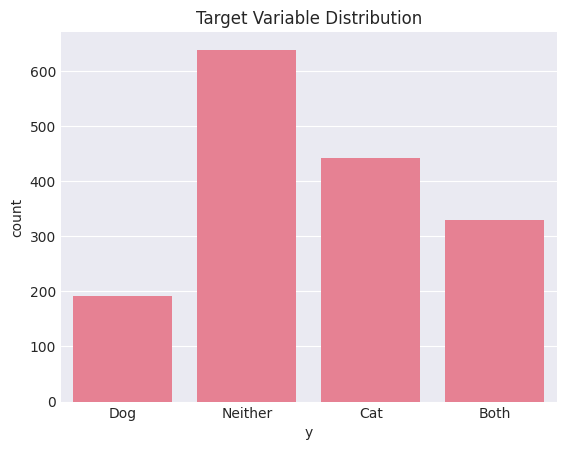

In [19]:
df['y'].value_counts()
sns.countplot(data=df, x='y')
plt.title('Target Variable Distribution')
plt.show()


### 4.3 Feature Distributions

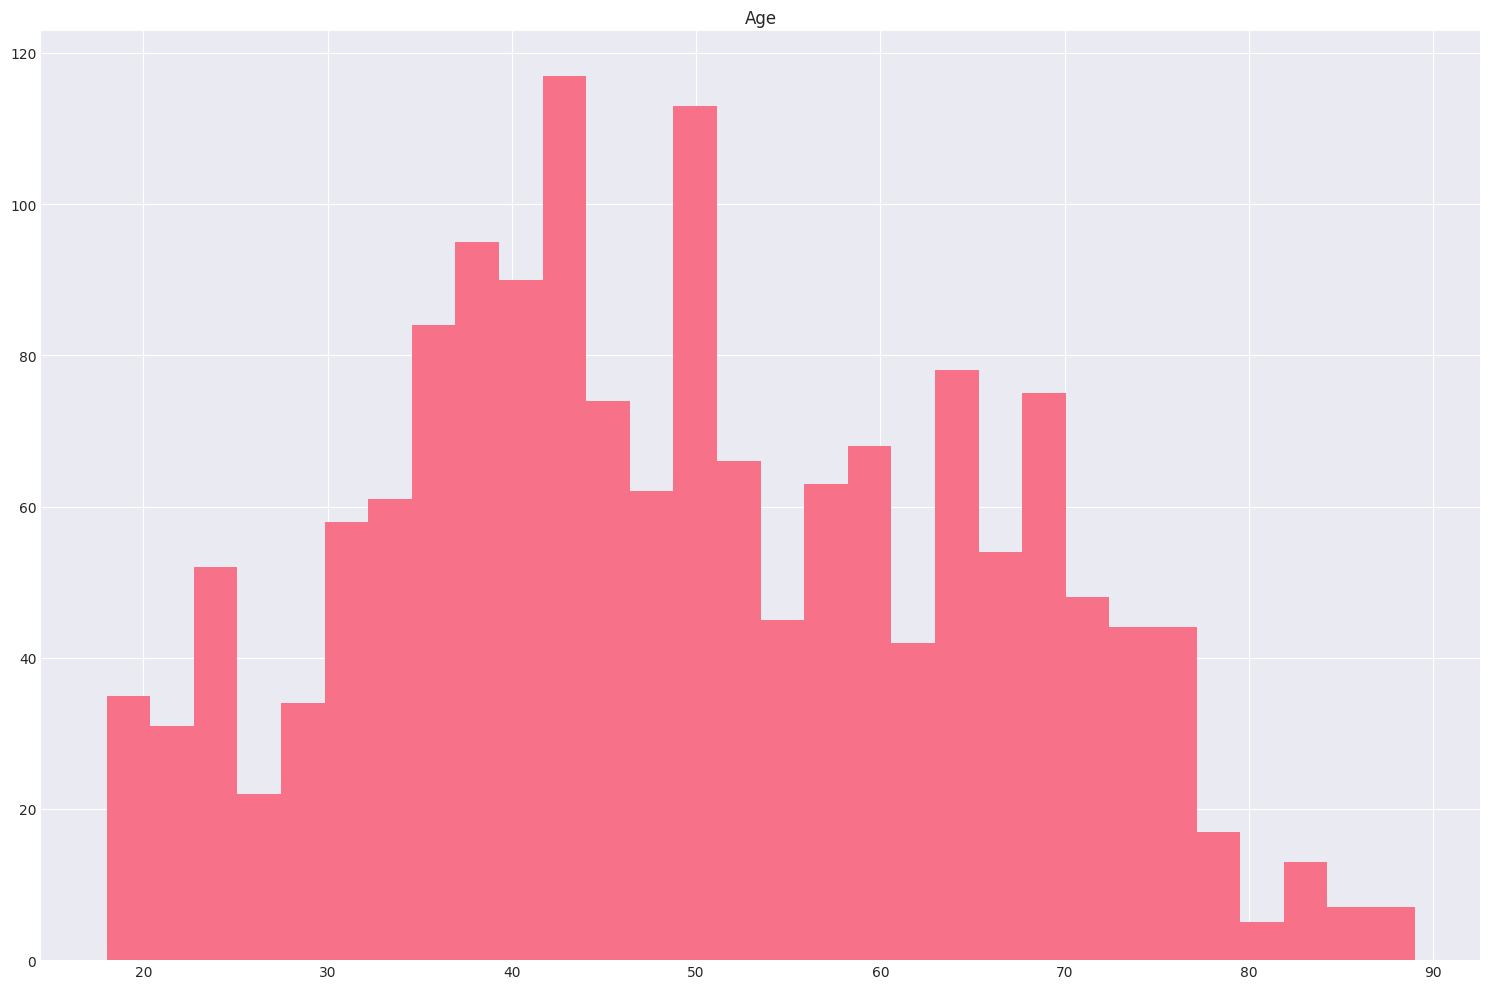

In [20]:
numerical_cols = ['AGE']
df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.title("Age")
plt.tight_layout()
plt.show()


### 4.4 Correlation Analysis

The only numerical feature is AGE. There is almost no sense to calculate correlation with categorical columns. 

### 4.5 Feature Importance Analysis (Initial)

Mutual information between each feature and the target variable can give us an initial idea of feature importance but it should be noted that it only captures individual feature importance and does not account for interactions between features. Let's also check interfeature correlations:


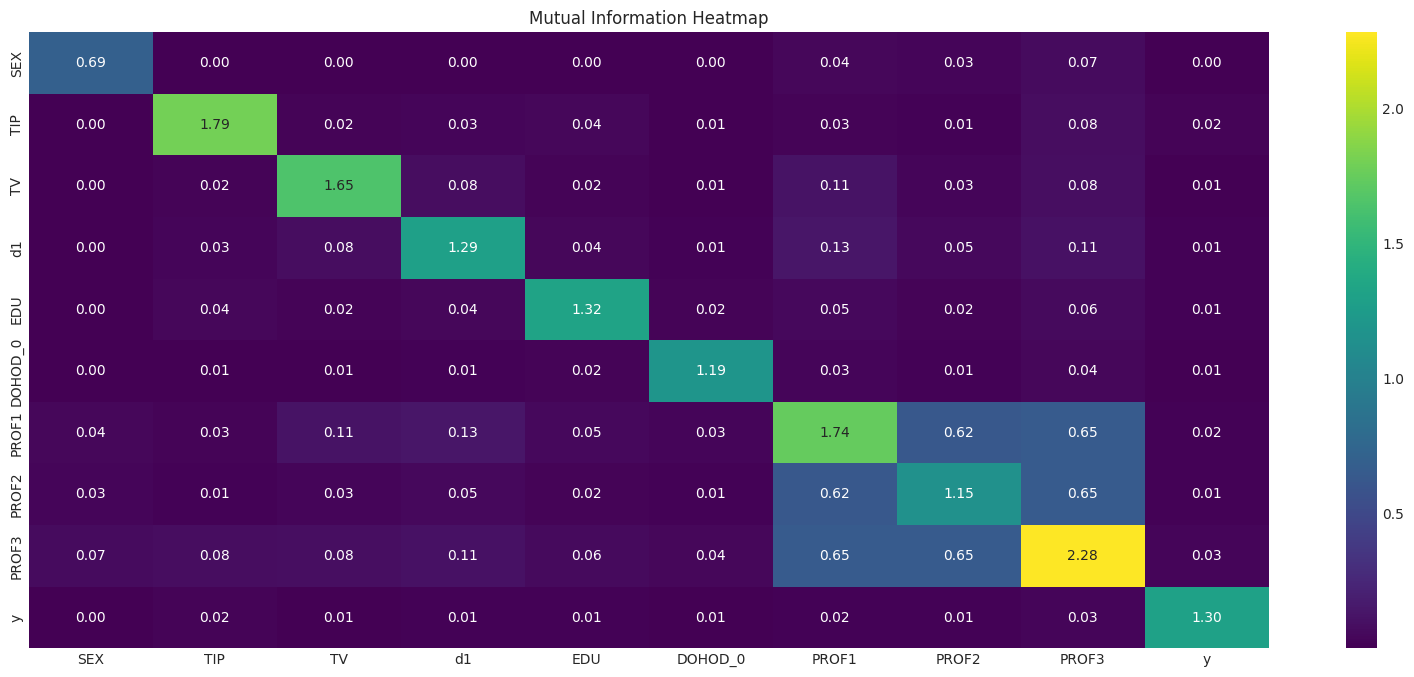

In [23]:

def mutual_info_df(df):
    cols = df.columns
    n = len(cols)
    mi_matrix = pd.DataFrame(np.zeros((n, n)), columns=cols, index=cols)
    
    for i in range(n):
        for j in range(i, n):
            x, y = df[cols[i]], df[cols[j]]
            mi = mutual_info_score(x,y)
            mi_matrix.iloc[i, j] = mi
            mi_matrix.iloc[j, i] = mi  # symmetric
            
    return mi_matrix
    
df_mi = mutual_info_df(df[[c for c in df.columns if c != 'AGE']])
plt.figure(figsize=(20, 8))
sns.heatmap(df_mi, annot=True, fmt=".2f", cmap="viridis")
plt.title("Mutual Information Heatmap")
plt.show()


## 5. Data Preparation for Modeling

<!-- TODO: Prepare data for machine learning models -->

In [ ]:
df_train_val, df_test  = train_test_split(df, test_size=.2, random_state=SEED)
df_train, df_val  = train_test_split(df_train_val, test_size=.25, random_state=SEED) # 0.25 x 0.8 = 0.2

df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

y_train = df_train.y
df_train.drop(columns=['y'], inplace=True)

y_test = df_test.y
df_test.drop(columns=['y'], inplace=True)

y_val = df_val.y
df_val.drop(columns=['y'], inplace=True)

In [31]:
dv = DictVectorizer(sparse=False)
dv.fit(df_train.to_dict(orient='records'))

target_labels = ['Neither','Cat','Both','Dog']

X_train = dv.transform(df_train.to_dict(orient='records'))
X_val = dv.transform(df_val.to_dict(orient='records'))
X_test = dv.transform(df_test.to_dict(orient='records'))

## 6. Model Training

<!--
Evaluation Criteria - Model Training (3 points max):
- 0 points: No model training
- 1 point: Trained only one model, no parameter tuning
- 2 points: Trained multiple models (linear and tree-based). 
  For neural networks: tried multiple variations - with dropout or without, with extra inner layers or without
- 3 points: Trained multiple models and tuned their parameters. 
  For neural networks: same as previous, but also with tuning: adjusting learning rate, dropout rate, size of inner layer, etc.

TODO: Train multiple models with parameter tuning
- Train at least one linear model (LogisticRegression, LinearRegression, etc.)
- Train at least one tree-based model (RandomForest, XGBoost, etc.)
- Tune hyperparameters for best models
- Compare model performance
-->

### 6.00001 Metrics

For classification tasks, we will evaluate model performance using the following metrics:
- Accuracy
- ROC AUC

In [85]:
def print_classification_metrics(model, X, y):
    for lbl in target_labels:
        y_binary = (y == lbl).astype(int)
        y_pred_proba = model.predict_proba(X)[:, model.classes_.tolist().index(lbl)]
        auc = roc_auc_score(y_binary, y_pred_proba)
        print(f"ROC AUC for class {lbl}: {auc:.4f}")
    
    avg_accuracy = model.score(X, y)
    print(f"Overall Accuracy: {avg_accuracy:.4f}")

def print_xgb_classification_metrics(xgb_model, dmatrix, y_true, label_encoder):
    """Print metrics for XGBoost model trained with xgb.train()"""
    # Get predictions (returns probability matrix)
    y_pred_proba = xgb_model.predict(dmatrix)
    
    # Get predicted classes
    y_pred_encoded = y_pred_proba.argmax(axis=1)
    y_pred = label_encoder.inverse_transform(y_pred_encoded)
    
    # Calculate ROC AUC for each class
    for i, lbl in enumerate(target_labels):
        y_binary = (y_true == lbl).astype(int)
        auc = roc_auc_score(y_binary, y_pred_proba[:, i])
        print(f"ROC AUC for class {lbl}: {auc:.4f}")
    
    # Calculate accuracy
    accuracy = (y_pred == y_true).mean()
    print(f"Overall Accuracy: {accuracy:.4f}")


### 6.1 Baseline Model

In [55]:
from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)

print_classification_metrics(baseline, X_val, y_val)


ROC AUC for class Neither: 0.5000
ROC AUC for class Cat: 0.5000
ROC AUC for class Both: 0.5000
ROC AUC for class Dog: 0.5000
Overall Accuracy: 0.3988


### 6.2 Linear Model(LogReg)

In [56]:
m = LogisticRegression(max_iter=1000, C=0.1, multi_class='ovr', 
                       random_state=SEED, solver='liblinear')
m.fit(X_train, y_train)
print_classification_metrics(m, X_val, y_val)


ROC AUC for class Neither: 0.5691
ROC AUC for class Cat: 0.5455
ROC AUC for class Both: 0.6523
ROC AUC for class Dog: 0.5046
Overall Accuracy: 0.3988


### 6.3 Tree-Based Models


#### 6.3.1 Decision Tree

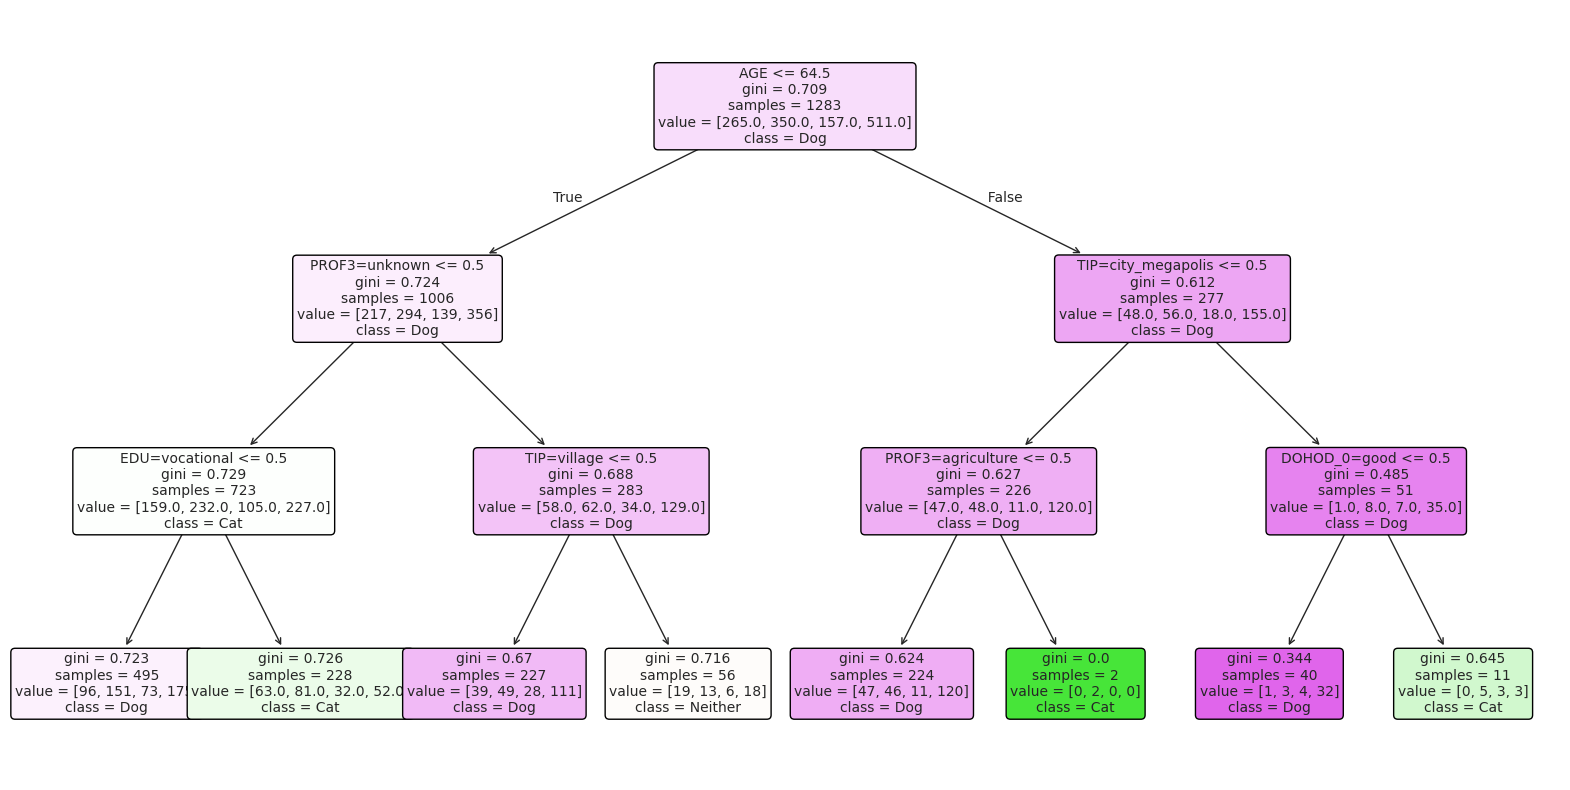

In [70]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

plt.figure(figsize=(20, 10))

plot_tree(dt, 
          filled=True, 
          feature_names=dv.get_feature_names_out(),  # Use DictVectorizer's feature names
          class_names=target_labels,  # Show actual class names
          fontsize=10,

          rounded=True)
plt.show()

In [73]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier(max_depth=10)
dt.fit(X_train, y_train)

print_classification_metrics(dt, X_val, y_val)

ROC AUC for class Neither: 0.5070
ROC AUC for class Cat: 0.4618
ROC AUC for class Both: 0.5281
ROC AUC for class Dog: 0.5262
Overall Accuracy: 0.3209


In [79]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED)
forest.fit(X_train, y_train)
print_classification_metrics(forest, X_val, y_val)

ROC AUC for class Neither: 0.5546
ROC AUC for class Cat: 0.5057
ROC AUC for class Both: 0.5955
ROC AUC for class Dog: 0.4807
Overall Accuracy: 0.4019


In [ ]:
import xgboost as xgb

xgb_parameters = {
    'objective': 'multi:softprob',
    'num_class': 4,
    'eval_metric': 'mlogloss',
    'seed': SEED,
    'use_label_encoder': False,

    'eta': 0.1, 
    'max_depth': 100,
    'min_child_weight': 1,
    
    'nthread': 8,
    
    'verbosity': 1,
}

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

dtrain = xgb.DMatrix(X_train, label = y_train_encoded)
dval = xgb.DMatrix(X_val, label = y_val_encoded)

xgb_model = xgb.train(
    params = xgb_parameters,
    dtrain = dtrain,
    num_boost_round = 1000,
    evals = [(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds = 10,
    verbose_eval = 10
)


print_xgb_classification_metrics(xgb_model, dval, y_val, le)


[0]	train-mlogloss:1.13211	val-mlogloss:1.33996
[10]	train-mlogloss:0.31974	val-mlogloss:1.52928
ROC AUC for class Neither: 0.5082
ROC AUC for class Cat: 0.5337
ROC AUC for class Both: 0.5201
ROC AUC for class Dog: 0.4714
Overall Accuracy: 0.3645


### 6.4 Hyperparameter Tuning

In [ ]:
# TODO: Perform hyperparameter tuning on best performing models
# Option 1: Grid Search
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, 30],
#     'min_samples_split': [2, 5, 10]
# }
# grid_search = GridSearchCV(
#     RandomForestClassifier(random_state=RANDOM_STATE),
#     param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1
# )
# grid_search.fit(X_train, y_train)
# print(f"Best parameters: {grid_search.best_params_}")
# print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Option 2: Random Search
# from sklearn.model_selection import RandomizedSearchCV
# param_distributions = {
#     'n_estimators': [100, 200, 300, 400, 500],
#     'max_depth': [10, 20, 30, 40, 50],
#     'min_samples_split': [2, 5, 10, 15]
# }
# random_search = RandomizedSearchCV(
#     RandomForestClassifier(random_state=RANDOM_STATE),
#     param_distributions,
#     n_iter=20,
#     cv=5,
#     scoring='accuracy',
#     random_state=RANDOM_STATE,
#     n_jobs=-1
# )
# random_search.fit(X_train, y_train)
# print(f"Best parameters: {random_search.best_params_}")
# print(f"Best cross-validation score: {random_search.best_score_:.4f}")

### 6.5 Model Comparison

In [ ]:
# TODO: Compare all models and select the best one
# results = {
#     'Baseline': baseline_score,
#     'Logistic Regression': log_reg_score,
#     'Random Forest': rf_score,
#     'XGBoost': xgb_score,
#     'Tuned Model': grid_search.best_score_
# }
# 
# results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
# results_df = results_df.sort_values('Accuracy', ascending=False)
# print(results_df)
# 
# plt.figure(figsize=(10, 6))
# sns.barplot(data=results_df, x='Accuracy', y='Model')
# plt.title('Model Comparison')
# plt.show()

### 6.6 Final Model Training

In [ ]:
# TODO: Train the final model with best parameters on full training data
# final_model = RandomForestClassifier(**grid_search.best_params_, random_state=RANDOM_STATE)
# final_model.fit(X_train_full, y_train_full)
# 
# # Evaluate on test set
# test_score = final_model.score(X_test, y_test)
# print(f"Final model test accuracy: {test_score:.4f}")

## 7. Model Evaluation

In [ ]:
# TODO: Evaluate the final model in detail
# y_pred = final_model.predict(X_test)
# 
# For classification:
# print(classification_report(y_test, y_pred))
# 
# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title('Confusion Matrix')
# plt.ylabel('True Label')
# plt.xlabel('Predicted Label')
# plt.show()

# For regression:
# from sklearn.metrics import mean_absolute_error, r2_score
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# mae = mean_absolute_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
# print(f"RMSE: {rmse:.4f}")
# print(f"MAE: {mae:.4f}")
# print(f"R²: {r2:.4f}")
# 
# # Residual plot
# residuals = y_test - y_pred
# plt.scatter(y_pred, residuals)
# plt.axhline(y=0, color='r', linestyle='--')
# plt.xlabel('Predicted Values')
# plt.ylabel('Residuals')
# plt.title('Residual Plot')
# plt.show()

## 8. Feature Importance (Final Model)

In [ ]:
# TODO: Analyze feature importance from the final model
# For tree-based models:
# feature_importance = pd.DataFrame({
#     'feature': X.columns,
#     'importance': final_model.feature_importances_
# }).sort_values('importance', ascending=False)
# 
# plt.figure(figsize=(10, 6))
# sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
# plt.title('Top 10 Important Features')
# plt.show()

## 9. Save the Model

<!--
Evaluation Criteria - Exporting notebook to script (1 point max):
- 0 points: No script for training a model
- 1 point: The logic for training the model is exported to a separate script

TODO: Save the final model to a file
- This will be used in the train.py script
- The saved model will be loaded in predict.py for the web service
-->

In [ ]:
# TODO: Save the final model
# Option 1: Pickle
# import pickle
# with open('model.pkl', 'wb') as f:
#     pickle.dump(final_model, f)
# 
# # Also save the scaler if you used one
# with open('scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# Option 2: Joblib (better for large models)
# import joblib
# joblib.dump(final_model, 'model.joblib')
# joblib.dump(scaler, 'scaler.joblib')

# Option 3: BentoML
# import bentoml
# bentoml.sklearn.save_model('model_name', final_model)

# print("Model saved successfully!")

## 10. Next Steps

<!--
After completing this notebook, you need to:

1. Create train.py script (1 point):
   - Export the training logic from this notebook
   - Should train and save the final model

2. Create predict.py script (1 point):
   - Load the saved model
   - Create a web service (Flask, FastAPI, or BentoML)
   - Serve predictions via API

3. Dependency Management (2 points max):
   - Create requirements.txt or Pipfile (1 point)
   - Use virtual environment and document it (2 points)

4. Containerization (2 points max):
   - Create Dockerfile (1 point)
   - Document how to build and run container (2 points)

5. Cloud Deployment - BONUS (2 points max):
   - Deploy to cloud or Kubernetes (1-2 points)
   - Provide URL or video/screenshot of testing

6. Update README.md (2 points max):
   - Describe the problem clearly (2 points)
   - Add instructions on how to run the project
   - Include dataset information

Total possible points: 16
-->

## Summary

<!-- 
TODO: Write a brief summary of:
- The problem you solved
- Key findings from EDA
- Models you tried
- Final model performance
- Next steps or potential improvements
-->